In [46]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [ ]:
iris = load_iris()
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [ ]:
df =pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)
df["species"]= iris.target_names[iris.target]
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("Number of rows: ", df.shape[0])
print("Number of columns", df.shape[1])

Number of rows:  150
Number of columns 5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [ ]:
print(df["species"].unique())

['setosa' 'versicolor' 'virginica']


In [ ]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


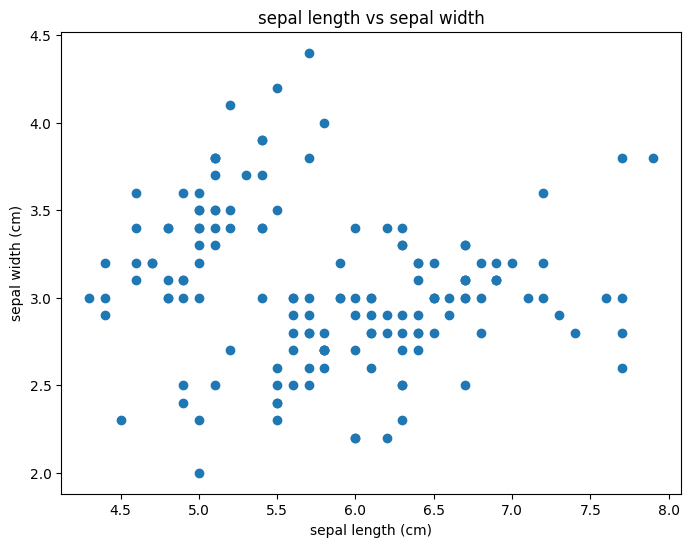

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["sepal length (cm)"],
    df["sepal width (cm)"],
)
plt.xlabel("sepal length (cm)")
plt.ylabel("sepal width (cm)")
plt.title("sepal length vs sepal width")

plt.show()

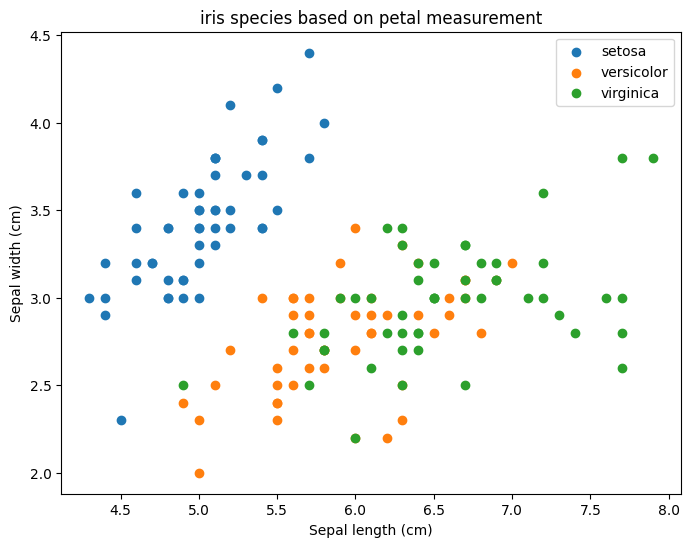

In [ ]:
plt.figure(figsize=(8, 6))

for species in df["species"].unique():
    subset = df[df["species"] == species]

    plt.scatter(
        subset["sepal length (cm)"],
        subset["sepal width (cm)"],
        label=species
    )

plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("iris species based on petal measurement")
plt.legend()



In [ ]:
x = iris.data
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(x_train))
print("Testing observations:", len(x_test))


Training observations: 120
Testing observations: 30


In [ ]:
model = KNeighborsClassifier(n_neighbors=3)

In [ ]:
model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [30]:
model = KNeighborsClassifier(n_neighbors=3)

In [31]:

model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred=model.predict(x_test)
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
print("Actual:")
print(y_test)

print("Predicted:")
print(y_pred)



Actual:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Predicted:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)



Accuracy:  1.0


In [35]:
new_flower = [(6,0, 2,7, 5,1, 1.6)]

In [36]:
new_flower = [[6.0, 2.7, 5.1, 1.6]]

prediction = model.predict(new_flower)

print(
    "predicted species:",
    iris.target_names[prediction[0]]
)



predicted species: virginica


In [37]:
probabilities = model.predict_proba(new_flower)
print(probabilities)

[[0.         0.33333333 0.66666667]]


In [40]:
probabilities = model.predict_proba(new_flower)

for species, probability in zip(
    iris.target_names,
    probabilities[0]
):
    print(f"{species}: {probability:.2%}")


setosa: 0.00%
versicolor: 33.33%
virginica: 66.67%


In [47]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"k={k}, accuracy = {accuracy:.2f}")


k=1, accuracy = 1.00
k=3, accuracy = 1.00
k=5, accuracy = 1.00
k=7, accuracy = 0.97
k=9, accuracy = 1.00


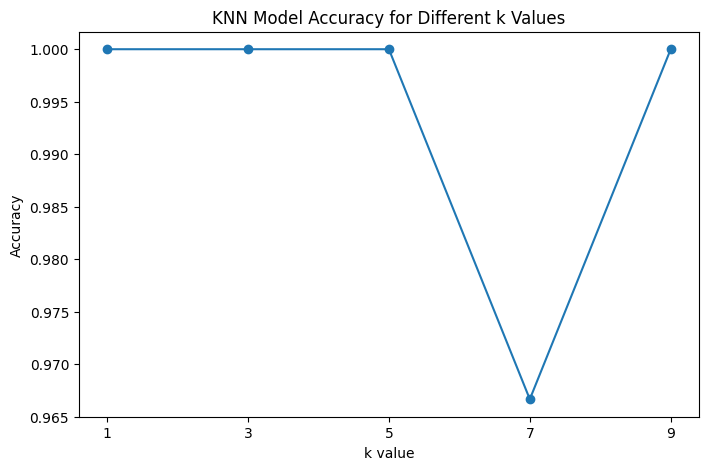

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracies,
    marker="o"
)

plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("KNN Model Accuracy for Different k Values")

plt.xticks(k_values)

plt.show()


In [51]:
results = pd.DataFrame({
    "Actual": iris.target_names[y_test],
    "Predicted": iris.target_names[y_pred]
})

results.head(10)


,Actual,Predicted
0,versicolor,versicolor
1,setosa,setosa
2,virginica,virginica
3,versicolor,versicolor
4,versicolor,versicolor
5,setosa,setosa
6,versicolor,versicolor
7,virginica,virginica
8,versicolor,versicolor
9,versicolor,versicolor


In [53]:
results["Correct"] = (
    results["Actual"] == results["Predicted"]
)

results.head(10)


,Actual,Predicted,Correct
0,versicolor,versicolor,True
1,setosa,setosa,True
2,virginica,virginica,True
3,versicolor,versicolor,True
4,versicolor,versicolor,True
5,setosa,setosa,True
6,versicolor,versicolor,True
7,virginica,virginica,True
8,versicolor,versicolor,True
9,versicolor,versicolor,True
